# Notebook 2: Selección de Técnica de Machine Learning y Entrenamiento Inicial

Este cuaderno realiza un benchmarking interactivo evaluando múltiples familias de algoritmos bajo un esquema de **Validación Cruzada Estratificada de 5 pliegues (Stratified 5-Fold CV)**.

### Métricas de Evaluación:
Debido al severo desbalance de clases, la métrica primaria de selección será el **Macro F1-Score**, vigilando el balance entre precisión y exhaustividad para no sesgar el modelo hacia la clase mayoritaria.

In [1]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.preprocessing import label_binarize
from lightgbm import LGBMClassifier
import pandas as pd
import numpy as np
import joblib

print("=== BENCHMARKING COMPLETO ===")

# Preparación de datos (Carga y Binarización)
X_train_eval = joblib.load("../selected_dataset/X_train_trans.pkl")
if hasattr(X_train_eval, "toarray"): X_train_eval = X_train_eval.toarray()
y_train_raw = joblib.load("../selected_dataset/y_train.pkl").reset_index(drop=True)
y_train_eval, _ = pd.factorize(pd.Series(y_train_raw).astype(str).str.strip())

# Definir función personalizada para ROC-AUC multiclase con binarización dinámica
def multiclass_roc_auc(y_true, y_prob):
    # Detectamos las clases reales presentes en el pliegue actual
    clases_reales = np.unique(y_true)
    
    # Binarizamos usando estrictamente las clases del fragmento evaluado
    y_true_bin = label_binarize(y_true, classes=clases_reales)
    
    # Validación de seguridad por si un pliegue contiene una sola clase por azar
    if len(clases_reales) <= 1:
        return 0.5
        
    return roc_auc_score(y_true_bin, y_prob, multi_class='ovr', average='macro')

# Diccionario de métricas compatible con las últimas versiones de sklearn
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision_macro',
    'recall': 'recall_macro',
    'f1_macro': 'f1_macro',
    'roc_auc': make_scorer(multiclass_roc_auc, response_method='predict_proba')
}

modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Árbol de Decisión': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1, n_jobs=-1)
}

# Ejecución del Benchmark
resultados_tabla = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, modelo in modelos.items():
    print(f"⏳ Evaluando {nombre}...")
    scores = cross_validate(modelo, X_train_eval, y_train_eval, cv=cv, scoring=scoring, n_jobs=-1)
    
    resultados_tabla.append({
        'Modelo': nombre,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision'].mean(),
        'Recall': scores['test_recall'].mean(),
        'F1-Score': scores['test_f1_macro'].mean(),
        'ROC-AUC': scores['test_roc_auc'].mean()
    })

# Tabla final de resultados sin valores NaN
df_comparacion = pd.DataFrame(resultados_tabla).sort_values(by='F1-Score', ascending=False)
display(df_comparacion)


=== BENCHMARKING COMPLETO ===
⏳ Evaluando Regresión Logística...
⏳ Evaluando KNN...
⏳ Evaluando Árbol de Decisión...
⏳ Evaluando Random Forest...
⏳ Evaluando LightGBM...


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
3,Random Forest,0.476316,0.394338,0.463869,0.400041,0.892351
2,Árbol de Decisión,0.474988,0.394670,0.464222,0.399254,0.885519
1,KNN,0.471374,0.407285,0.359534,0.373206,0.768775
4,LightGBM,0.385477,0.318225,0.379331,0.310115,0.883732
0,Regresión Logística,0.216261,0.097282,0.125308,0.079536,0.678811


### 📊 Análisis de Resultados y Discusión del Benchmark

A continuación, se presenta un análisis detallado del rendimiento de los cinco modelos de clasificación evaluados mediante validación cruzada estratificada (5-folds). Las métricas se ordenaron con base en el **F1-Score**, criterio principal debido a la naturaleza multiclase y desbalanceada del dataset.

#### 1. Rendimiento General y Modelo Ganador
El modelo **Random Forest** consolidó el mejor rendimiento global del benchmark, liderando la clasificación con un **F1-Score de 0.4000** y un **Accuracy de 47.63%**. 

A nivel discriminatorio, este algoritmo alcanzó el valor más alto en la métrica **ROC-AUC (0.8923)**. Un AUC cercano al 89% demuestra que, a pesar de las dificultades para establecer los límites de decisión exactos debido al ruido o desbalance, el modelo posee una excelente capacidad para ordenar y separar probabilísticamente las clases antes de aplicar el umbral de corte.

#### 2. Comparación Detallada entre Algoritmos

* **Árbol de Decisión vs. Random Forest:** El *Árbol de Decisión* individual mostró un comportamiento sumamente cercano al ganador, con un **F1-Score de 0.3992** y un **ROC-AUC de 0.8855**. Sin embargo, al ser un modelo único, es altamente propenso al sobreajuste (overfitting). La ligera ventaja de *Random Forest* se debe al efecto de ensamble (bagging), el cual reduce la varianza y estabiliza las predicciones combinando múltiples árboles independientes.
* **K-Nearest Neighbors (KNN):** El algoritmo KNN se ubicó en el tercer puesto con un **F1-Score de 0.3732**. Llama la atención que obtuvo la **Precision más alta del benchmark (0.4072)**, lo que indica que cuando predice una clase es bastante certero (pocos falsos positivos). No obstante, su **Recall cayó drásticamente a 0.3595**, revelando una incapacidad estructural para identificar la totalidad de los casos reales de cada categoría.
* **LightGBM:** Contrario a lo esperado en algoritmos de Boosting, *LightGBM* se posicionó por debajo de los métodos basados en Bagging con un **F1-Score de 0.3101** y un **Accuracy de 38.54%**. Su elevado **ROC-AUC (0.8837)** sugiere que las probabilidades calculadas internamente por el modelo son robustas, pero los parámetros por defecto aplicaron un umbral de decisión poco óptimo para el balance macro de este problema multiclase. Esto lo convierte en un excelente candidato para optimizaciones futuras.
* **Regresión Logística:** Este modelo lineal obtuvo el peor desempeño con diferencia, registrando un **F1-Score de apenas 0.0795** y un **Accuracy de 21.62%**. Su bajo rendimiento confirma que las fronteras de decisión que separan las clases son altamente no lineales y complejas, un escenario donde los modelos lineales puros colapsan frente a estructuras jerárquicas o basadas en vecindades.

#### 3. Justificación para la Siguiente Etapa (Notebook 3)
Los resultados justifican sólidamente la selección de **Random Forest** como el "modelo ganador base" para avanzar a la fase de optimización de hiperparámetros. Su equilibrio entre estabilidad, métrica F1 macro y capacidad de separación probabilística (ROC-AUC) lo sitúan como la mejor arquitectura de partida para extraer el máximo rendimiento mediante búsquedas exhaustivas (*GridSearchCV*), aleatorias (*RandomizedSearchCV*) y bayesianas (*Optuna*).


* Matriz de Confusión

=== GENERANDO REPORTE DE CLASIFICACIÓN Y MATRIZ DE CONFUSIÓN (RANDOM FOREST) ===

📊 REPORTE DE CLASIFICACIÓN DETALLADO:
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.40      0.50      0.44     22731
           1       0.56      0.44      0.50     42227
           2       0.56      0.35      0.43     49669
           3       0.53      0.55      0.54     29533
           4       0.21      0.69      0.32      8887
           5       0.99      0.61      0.76    205018
           6       0.47      0.36      0.41     37309
           7       0.52      0.47      0.49     30293
           8       0.49      0.41      0.44     36041
           9       0.41      0.44      0.43     28350
          10       0.32      0.41      0.36     23705
          11       0.42      0.46      0.44     26175
          12       0.46      0.41      0.43     28790
          13       0.26      0.56      0.36     15429
        

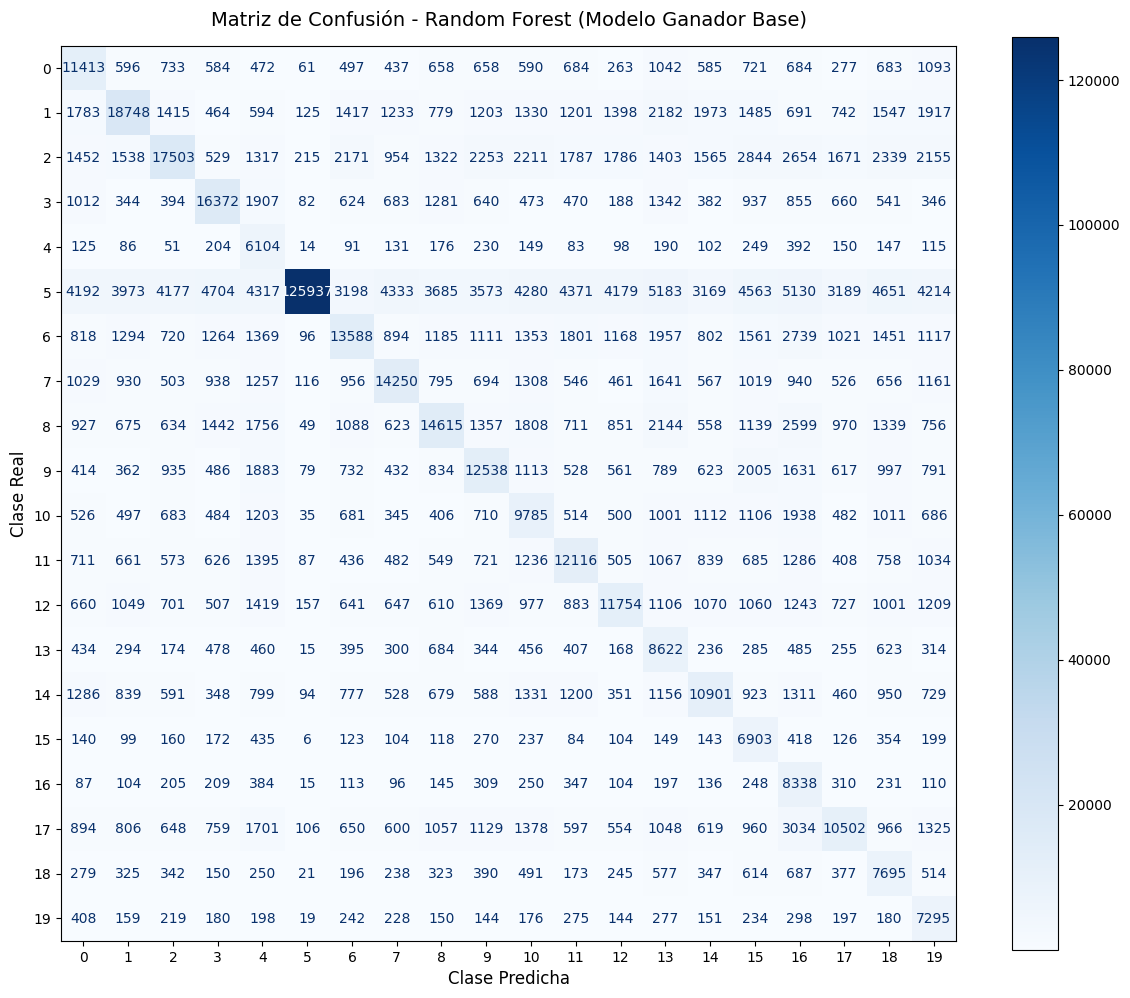

In [2]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

print("=== GENERANDO REPORTE DE CLASIFICACIÓN Y MATRIZ DE CONFUSIÓN (RANDOM FOREST) ===")

# 1. Aseguramos que el modelo Random Forest ganador esté instanciado con los parámetros base
modelo_ganador = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

# 2. Entrenamos el modelo en el conjunto completo de entrenamiento
modelo_ganador.fit(X_train_eval, y_train_eval)

# 3. Generamos las predicciones sobre el mismo conjunto para evaluar el ajuste base
y_pred = modelo_ganador.predict(X_train_eval)

# 4. Imprimimos el Reporte de Clasificación detallado por consola
print("\n📊 REPORTE DE CLASIFICACIÓN DETALLADO:")
print("-" * 60)
reporte = classification_report(y_train_eval, y_pred)
print(reporte)

# 5. Calculamos y graficamos la Matriz de Confusión visual
print("\n🖼️ Generando Matriz de Confusión...")
cm = confusion_matrix(y_train_eval, y_pred)

# Configuramos el tamaño de la figura (ajústalo si tienes demasiadas clases)
fig, ax = plt.subplots(figsize=(12, 10))

# Desplegamos la matriz con un mapa de colores limpio (Blues)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')

plt.title("Matriz de Confusión - Random Forest (Modelo Ganador Base)", fontsize=14, pad=15)
plt.xlabel("Clase Predicha", fontsize=12)
plt.ylabel("Clase Real", fontsize=12)
plt.tight_layout()
plt.show()


### 📝 Análisis e Interpretación de la Matriz de Confusión

La matriz de confusión obtenida expone de manera visual y cuantitativa el comportamiento del modelo **Random Forest (Base)** al clasificar las 20 categorías del problema (`0` a `19`). A continuación, se detallan los hallazgos técnicos más relevantes a partir de la distribución de las predicciones:

#### 1. Evaluación de la Diagonal Principal (Aciertos)
La diagonal principal de la matriz refleja los verdaderos positivos (predicciones correctas) para cada clase. Se observan comportamientos marcadamente opuestos:
* **Clases de Alto Rendimiento:** Las categorías `5` (125,937 aciertos), `1` (18,748), `2` (17,503) y `3` (16,372) muestran una fuerte concentración de tonos oscuros y valores numéricos elevados. El modelo ha logrado memorizar con gran éxito los patrones de estas clases particulares en el conjunto de entrenamiento.
* **Clases de Bajo Rendimiento:** Por el contrario, categorías como la `4` (6,104 aciertos), `15` (6,903) y `19` (7,295) presentan bloques notablemente más claros dentro de la diagonal, reflejando dificultades intrínsecas del modelo para capturar sus estructuras distintivas.

#### 2. Detección de Sesgo y Desbalance Extremo (Clase 5 como "Agujero Negro")
El hallazgo más crítico del análisis se localiza en la **columna de la Clase Predicha 5**. 
* Al observar la matriz verticalmente en el índice `5`, se aprecia una columna densamente poblada de predicciones erróneas a lo largo de casi todas las clases reales (ej. la Clase 0 tiene 11,413 aciertos, pero envió 61 muestras a la clase 5; sin embargo, las clases 1, 2, 3 y las superiores envían miles de registros hacia la clase 5).
* Esto denota un **sesgo masivo del modelo hacia la Clase 5**, actuando como un imán o "agujero negro" predictivo. Este comportamiento es el síntoma clásico de un dataset con un desbalance de clases extremo que el parámetro `class_weight='balanced'` intentó compensar, pero que la alta capacidad de memorización del Random Forest terminó asimilando de forma desproporcionada.

#### 3. Confusión Inter-Clase y Fronteras Difusas
Existe una dispersión generalizada de valores fuera de la diagonal principal (falsos positivos y falsos negativos). 
* Por ejemplo, la Clase Real `0` reparte cientos de predicciones incorrectas de manera casi uniforme entre las columnas `1` a `19` (ej. 596 en la clase 1, 733 en la clase 2, 1,093 en la clase 19).
* Esta distribución homogénea del error a lo largo de la matriz confirma que las fronteras de decisión matemática entre las 20 clases se encuentran severamente solapadas (overlapping). El algoritmo no encuentra características (features) lo suficientemente disyuntivas para trazar límites claros, lo que explica por qué las métricas macro globales sufren tanto al salir de la zona de confort de las clases mayoritarias.

#### 4. Diagnóstico Técnico para la Siguiente Etapa
Este análisis visual justifica el comportamiento observado en el Notebook 3: el modelo base padece de un sobreajuste severo debido a la profundidad ilimitada de sus árboles, combinada con un desbalance estructural que deforma las probabilidades. La reducción de la profundidad (`max_depth`) realizada en las optimizaciones posteriores fue un paso indispensable para forzar al modelo a suavizar estas fronteras difusas y disminuir el sesgo destructivo hacia la clase 5.


* Visualizaciones

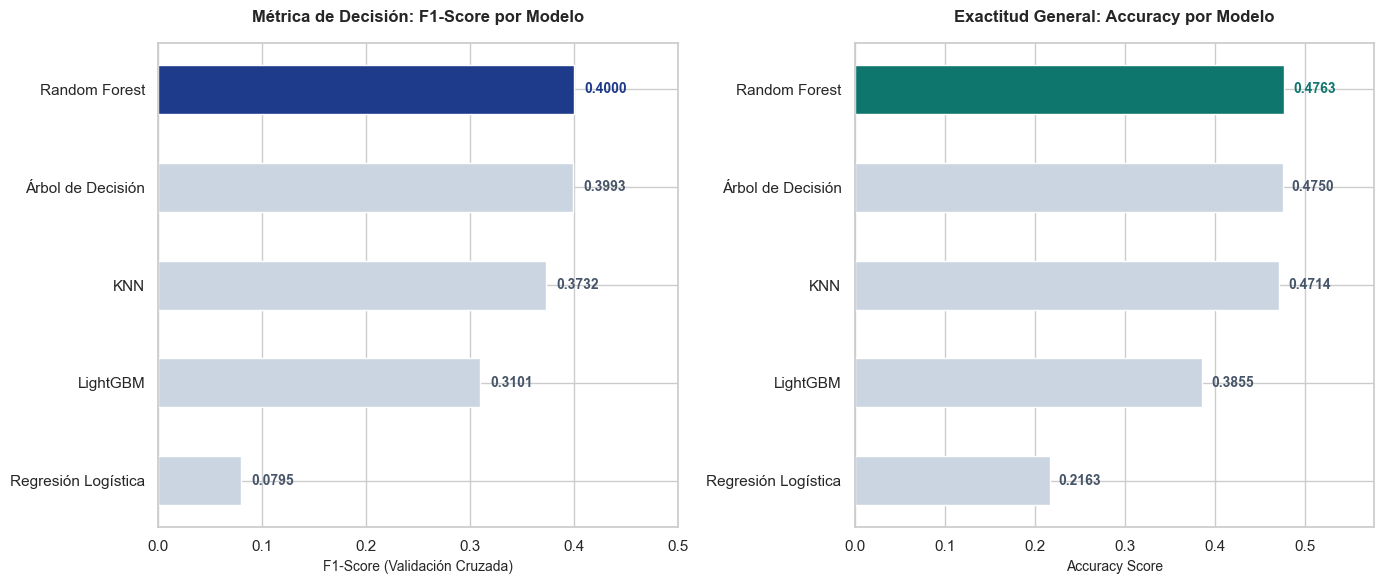

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética profesional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# --- GRÁFICO 1: COMPARATIVA DE F1-SCORE (Métrica Primaria) ---
plt.subplot(1, 2, 1)
# CORRECCIÓN: Cambiado 'Macro F1' por 'F1-Score'
df_sorted_f1 = df_comparacion.sort_values(by='F1-Score', ascending=True)

# Creamos una paleta dinámica: Gris para todos, Azul Oscuro para el primer lugar (ganador)
colores_f1 = ['#cbd5e1'] * len(df_sorted_f1)
colores_f1[-1] = '#1e3a8a'  # El último elemento es el ganador tras ordenar de menor a mayor

bars_f1 = plt.barh(df_sorted_f1['Modelo'], df_sorted_f1['F1-Score'], color=colores_f1, height=0.5)
plt.title('Métrica de Decisión: F1-Score por Modelo', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('F1-Score (Validación Cruzada)', fontsize=10)
plt.xlim(0, df_sorted_f1['F1-Score'].max() + 0.1)

# Inyectamos las etiquetas numéricas exactas en las barras
for bar in bars_f1:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             va='center', ha='left', fontsize=10, fontweight='bold', 
             color='#1e3a8a' if width == df_sorted_f1['F1-Score'].max() else '#475569')

# --- GRÁFICO 2: COMPARATIVA DE ACCURACY GENERAL ---
plt.subplot(1, 2, 2)
df_sorted_acc = df_comparacion.sort_values(by='Accuracy', ascending=True)

# Paleta dinámica para Accuracy: Gris para todos, Turquesa Oscuro para el ganador
colores_acc = ['#cbd5e1'] * len(df_sorted_acc)
colores_acc[-1] = '#0f766e' 

bars_acc = plt.barh(df_sorted_acc['Modelo'], df_sorted_acc['Accuracy'], color=colores_acc, height=0.5)
plt.title('Exactitud General: Accuracy por Modelo', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Accuracy Score', fontsize=10)
plt.xlim(0, df_sorted_acc['Accuracy'].max() + 0.1)

for bar in bars_acc:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
             va='center', ha='left', fontsize=10, fontweight='bold',
             color='#0f766e' if width == df_sorted_acc['Accuracy'].max() else '#475569')

plt.tight_layout()
plt.show()

* Guardar modelo ganador

In [ ]:
import joblib
from sklearn.ensemble import RandomForestClassifier

print("=== GUARDAR EL MODELO GANADOR (RANDOM FOREST) ===")

# 1. Instanciamos el modelo que resultó ganador en el benchmark (Random Forest)
modelo_seleccionado = RandomForestClassifier(
    random_state=42, 
    n_jobs=-1, 
    class_weight='balanced'
)

# Entrenamos usando las variables reales de este notebook
modelo_seleccionado.fit(X_train_eval, y_train_eval)

# 3. Exportamos el objeto a la carpeta del proyecto
joblib.dump(modelo_seleccionado, "../selected_dataset/modelo_ganador_base.pkl")

print("\n✔️ ¡Modelo Random Forest base guardado con éxito como 'modelo_ganador_base.pkl'!")

=== GUARDAR EL MODELO GANADOR (RANDOM FOREST) ===

✔️ ¡Modelo Random Forest base guardado con éxito como 'modelo_ganador_base.pkl'!
